In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tdc.single_pred import ADME

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)


# Compute from PyTDC

In [3]:
# Load the half_life_obach dataset from TDC
data = ADME(name='Half_Life_Obach', path = "../../data")
# data = ADME(name='Clearance_Microsome_AZ', path = "../../data")
# data = ADME(name='Clearance_Hepatocyte_AZ', path = "../../data")
df = data.get_data()

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)


Found local copy...
Loading...
Done!


Dataset shape: (667, 3)

First few rows:
        Drug_ID                                               Drug    Y
0    CHEMBL1754        CCN1CC(CCN2CCOCC2)C(c2ccccc2)(c2ccccc2)C1=O  4.1
1    CHEMBL1484  COC(=O)C1=C(C)NC(C)=C(C(=O)OCCN(C)Cc2ccccc2)C1...  4.1
2     CHEMBL478                               Clc1cccc(N2CCNCC2)c1  4.7
3    CHEMBL1097                   CCN(CC)CCNC(=O)c1ccc(NC(C)=O)cc1  6.4
4  CHEMBL517712    CN1[C@H]2CC[C@@H]1C[C@H](OC(=O)C(CO)c1ccccc1)C2  4.1

Column names: ['Drug_ID', 'Drug', 'Y']

Data types:
Drug_ID     object
Drug        object
Y          float64
dtype: object


In [4]:
# Display basic statistics
print("Statistical Summary")
print("=" * 50)
print(f"Count: {df['Y'].count()}")
print(f"Mean: {df['Y'].mean():.4f}")
print(f"Median: {df['Y'].median():.4f}")
print(f"Std Dev: {df['Y'].std():.4f}")
print(f"Min: {df['Y'].min():.4f}")
print(f"Max: {df['Y'].max():.4f}")
print(f"25th percentile: {df['Y'].quantile(0.25):.4f}")
print(f"75th percentile: {df['Y'].quantile(0.75):.4f}")
print(f"\nMissing values: {df['Y'].isna().sum()}")


Statistical Summary
Count: 667
Mean: 18.2129
Median: 4.2000
Std Dev: 81.8692
Min: 0.0650
Max: 1200.0000
25th percentile: 1.7500
75th percentile: 11.0000

Missing values: 0


In [6]:
df['Y'].min()

0.065

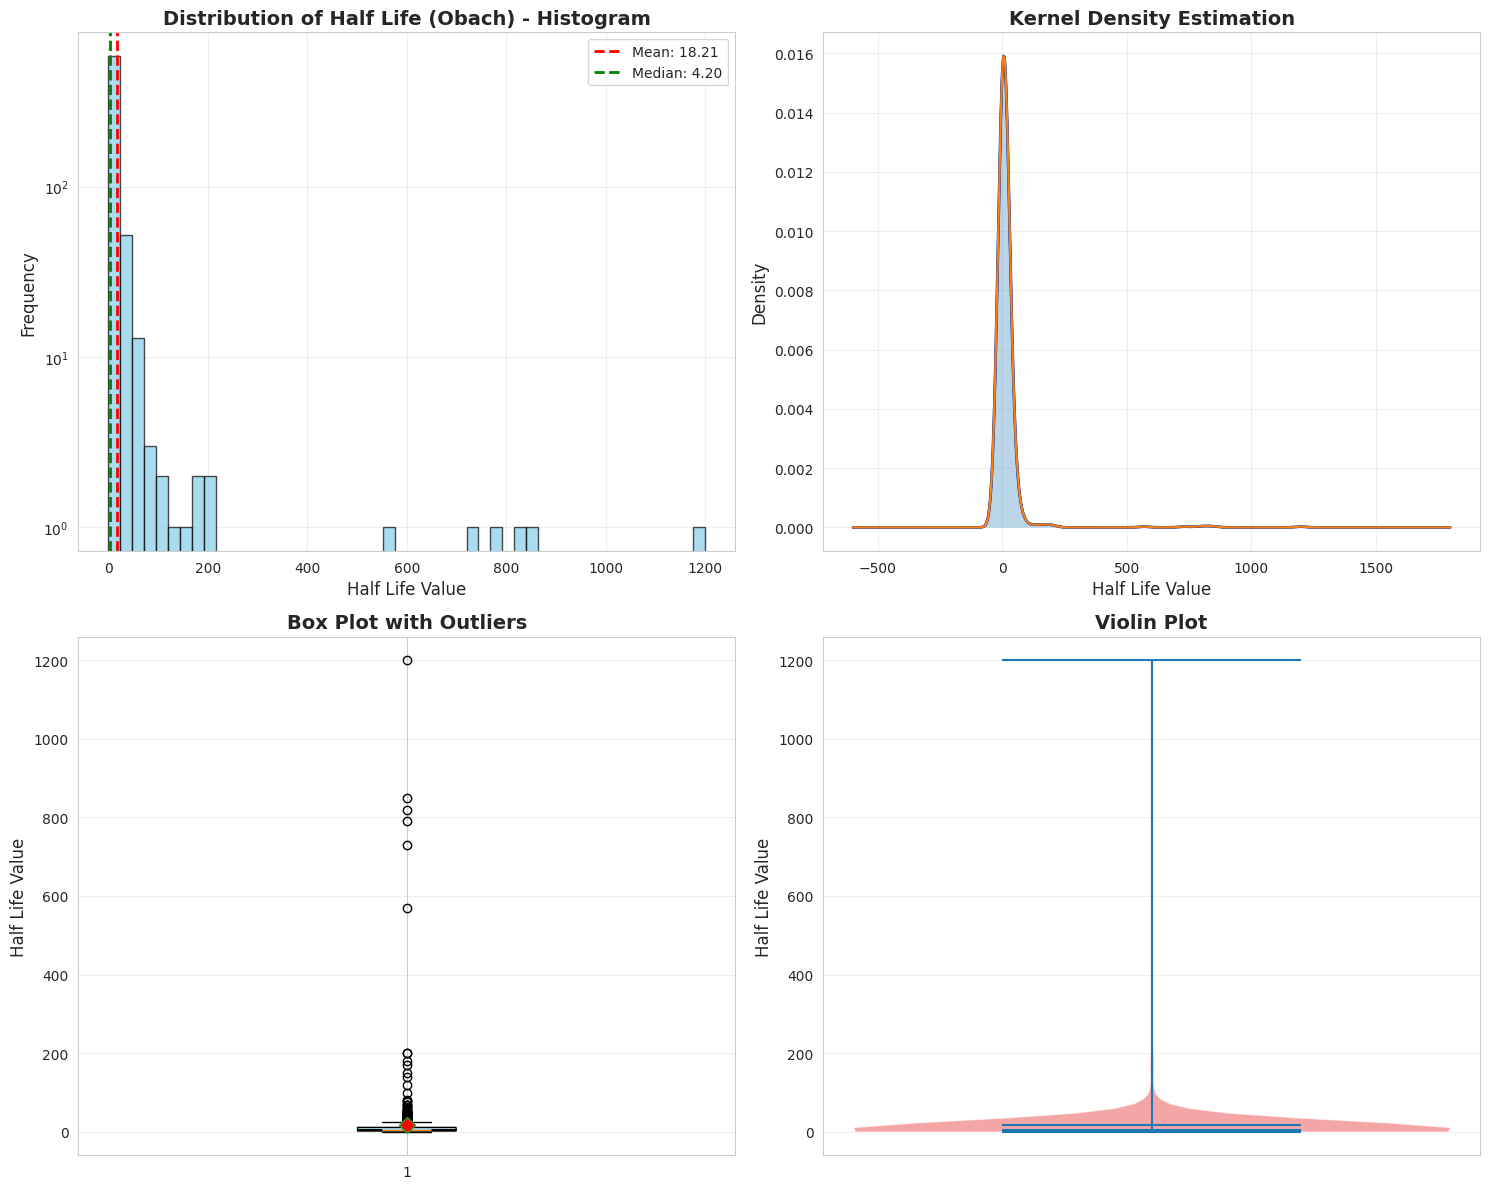


Plot saved as 'half_life_obach_distribution.png'


In [5]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histogram with KDE
axes[0, 0].hist(df['Y'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Half Life Value', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Half Life (Obach) - Histogram', fontsize=14, fontweight='bold')
axes[0, 0].axvline(df['Y'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Y"].mean():.2f}')
axes[0, 0].axvline(df['Y'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Y"].median():.2f}')
axes[0, 0].legend()
axes[0, 0].set_yscale("log")
axes[0, 0].grid(True, alpha=0.3)

# 2. KDE Plot
df['Y'].plot(kind='kde', ax=axes[0, 1], color='darkblue', linewidth=2)
axes[0, 1].set_xlabel('Half Life Value', fontsize=12)
axes[0, 1].set_ylabel('Density', fontsize=12)
axes[0, 1].set_title('Kernel Density Estimation', fontsize=14, fontweight='bold')
axes[0, 1].fill_between(df['Y'].plot(kind='kde', ax=axes[0, 1]).get_lines()[0].get_data()[0],
                         df['Y'].plot(kind='kde', ax=axes[0, 1]).get_lines()[0].get_data()[1],
                         alpha=0.3)
axes[0, 1].grid(True, alpha=0.3)

# 3. Box Plot
box = axes[1, 0].boxplot(df['Y'], vert=True, patch_artist=True, 
                         notch=True, showmeans=True,
                         meanprops=dict(marker='D', markerfacecolor='red', markersize=8))
box['boxes'][0].set_facecolor('lightblue')
axes[1, 0].set_ylabel('Half Life Value', fontsize=12)
axes[1, 0].set_title('Box Plot with Outliers', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Violin Plot
parts = axes[1, 1].violinplot([df['Y'].dropna()], positions=[0], showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('lightcoral')
    pc.set_alpha(0.7)
axes[1, 1].set_ylabel('Half Life Value', fontsize=12)
axes[1, 1].set_title('Violin Plot', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks([])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
# plt.savefig('half_life_obach_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved as 'half_life_obach_distribution.png'")


In [15]:
# Additional analysis: Check for skewness and outliers
from scipy import stats

skewness = stats.skew(df['Y'])
kurtosis = stats.kurtosis(df['Y'])

print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

# Identify outliers using IQR method
Q1 = df['Y'].quantile(0.25)
Q3 = df['Y'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Y'] < lower_bound) | (df['Y'] > upper_bound)]
print(f"\nNumber of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Lower bound: {lower_bound:.4f}")
print(f"Upper bound: {upper_bound:.4f}")


Skewness: 1.6086
Kurtosis: 1.3287

Number of outliers: 135 (12.25%)
Lower bound: -56.4900
Upper bound: 102.1500


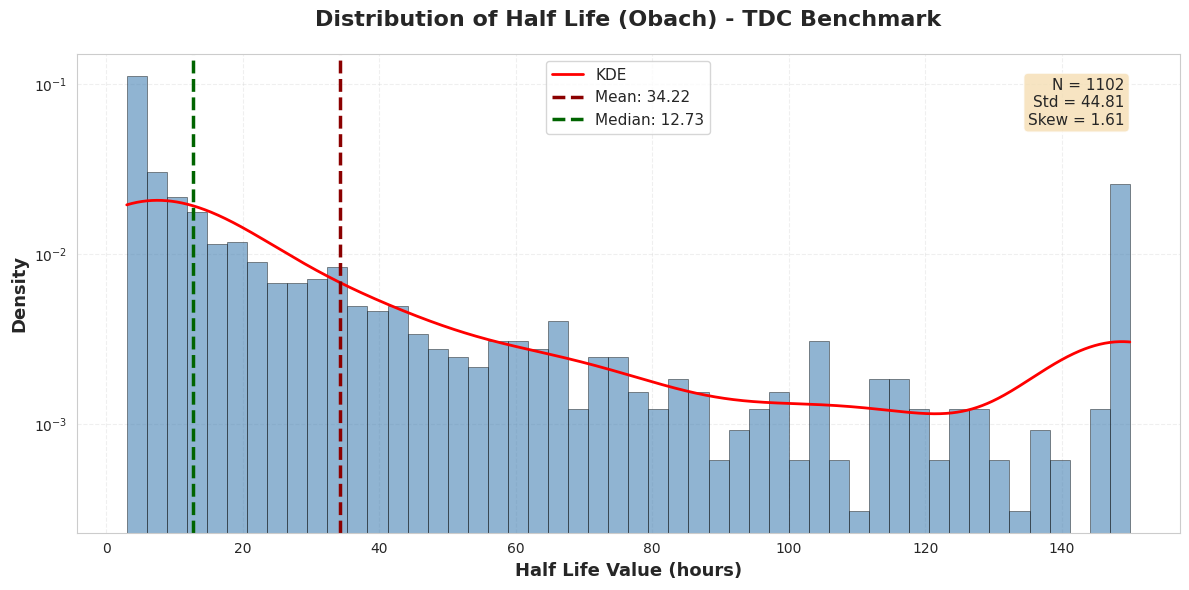


Main plot saved as 'half_life_obach_main.png'


In [16]:
# Create a single comprehensive plot with better aesthetics
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram with KDE overlay
n, bins, patches = ax.hist(df['Y'], bins=50, density=True, alpha=0.6, 
                            color='steelblue', edgecolor='black', linewidth=0.5)

# KDE overlay
from scipy.stats import gaussian_kde
kde = gaussian_kde(df['Y'].dropna())
x_range = np.linspace(df['Y'].min(), df['Y'].max(), 1000)
ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')

# Add mean and median lines
ax.axvline(df['Y'].mean(), color='darkred', linestyle='--', linewidth=2.5, 
           label=f'Mean: {df["Y"].mean():.2f}')
ax.axvline(df['Y'].median(), color='darkgreen', linestyle='--', linewidth=2.5, 
           label=f'Median: {df["Y"].median():.2f}')

ax.set_xlabel('Half Life Value (hours)', fontsize=13, fontweight='bold')
ax.set_ylabel('Density', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Half Life (Obach) - TDC Benchmark', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_yscale("log")
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')

# Add text box with statistics
textstr = f'N = {len(df)}\nStd = {df["Y"].std():.2f}\nSkew = {skewness:.2f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
# plt.savefig('half_life_obach_main.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMain plot saved as 'half_life_obach_main.png'")


# Cache

In [1]:
cache_path = "/home/shpark/prj-molrepr/datacache/neurips2023-small/a2c7cd7492a9a9070c2f8e095840cf78"